# Imports and Physical Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import cumulative_trapezoid
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

EXPLAIN PHYSICAL PARAMETERS HERE

In [32]:
# --- Set relevant physical parameters ---
gamma0 = 1.0                  # The Markovian decay rate
Lambda_moderate = 100*gamma0  # Spectral width for moderate coupling regime
Lambda_strong   = 0.1*gamma0  # Spectral width for strong coupling regime

t_mod    = np.linspace(1e-6, 4.0, 2000)   # Shorter window for moderate coupling
t_str = np.linspace(1e-6, 25.0, 5000)  # Longer window to hsee oscillations in stronger regime

# Assign colors for each approximation for the figures
colors = {
  'exact'  : 'black',
  'tcl4'   : 'blue',
  'tcl2'   : 'green',
  'gme'    : 'orange',
  'markov' : 'red',
}

# 1) The Exact Solution

In the report, we found that, the exact excited state amplitudes are 

\begin{equation}
    c_1(t) = e^{-\Lambda t/2}\left[\cosh\!\left(\frac{dt}{2}\right) 
    + \frac{\Lambda}{d}\sinh\!\left(\frac{dt}{2}\right)\right].
\end{equation}

In the 

In [17]:
def c1_exact(t, gamma0, Lambda):
  """
  The exact excited-state amplitude, c_1(t). This result is based on
  the derivation completed in my report. 
  
  Parameters
  ----------
  t      : array - time (units of 1/gamma0)
  gamma0 : float - the Markovian decay rate
  Lambda : float - spectral width

  Returns
  -------
  c1 : array - real amplitude (atom starts in excited state, cavity
               in vacuum)
  """

  discriminant = Lambda**2 - 2.0*gamma0*Lambda

  if discriminant > 0:
    # If this is the case, we're in the weak/moderate coupling regime
    # and d is real. We then get the following result from the report:
    d = np.sqrt(discriminant)
    return np.exp(-Lambda*t/2.0) * (np.cosh(d*t/2.0) + (Lambda/d) * np.sinh(d*t/2.0))

  elif discriminant == 0:
    # This is the critical condition where d = 0. Return the expression
    # we derove in the report for this regime:
    return np.exp(-Lambda*t/2.0) * (1.0 + Lambda*t/2.0)

  else:
    # This is the last regime: strong coupling. In this case, d is 
    # imaginary, so write the expression we found in the report:
    Omega = np.sqrt(-discriminant)
    return np.exp(-Lambda*t/2.0) * (np.cos(Omega*t/2.0) + (Lambda/Omega) * np.sin(Omega*t/2.0))

In the report, we also found the excited state populations, which we can simply write as the square of the c1_exact expressions. And so we can implement this as the following

In [18]:
def P11_exact(t, gamma0, Lambda):
  """
  Excited-state population.
  """
  return c1_exact(t, gamma0, Lambda)**2

Finally, for the weak coupling regime, we found an expression for $\gamma(t)$, which is the ... The code to implement this is below

In [19]:
def gamma_exact(t, gamma0, Lambda):
  """
  Time-dependent decay rate.
  Note that this diverges at the zeros of P_11(t) in the strong coupling
  regime -- this is physical and is not a numerical error.
  """

  discriminant = Lambda**2 - 2.0*gamma0*Lambda

  if discriminant > 0:
    # Invoke the equation we derove in the report for the weak/moderate
    # coupling case:
    d           = np.sqrt(discriminant)
    numerator   = 2.0*gamma0*Lambda*np.sinh(d*t/2.0)
    denominator = d*np.cosh(d*t/2.0) + Lambda*np.sinh(d*t/2.0)
    return numerator/denominator

  elif discriminant == 0:
    # This is the critical condition where d = 0. Write the expression
    # we found in the report:
    numerator   = gamma0*Lambda*t
    denominator = 1.0 + Lambda*t/2.0
    return numerator/denominator

  else:
    # This is the strong coupling regime. Again, use the expression we
    # derove in the report:
    Omega       = np.sqrt(-discriminant)
    numerator   = 2.0*gamma0*Lambda*np.sin(Omega*t/2.0)
    denominator = Omega*np.cos(Omega*t/2.0) + Lambda*np.sin(Omega*t/2.0)
    return numerator/denominator

# 2) The Markovian Master Equation

In the write-up, we found that the Markovian master equation gives us
$$
P_{11}(t) = P_{11}(0)\,e^{-\gamma_0 t}.
$$
Therefore, the following is going to be the numerical implementation of this result.

In the Born-Markov limit, the decay rate is constant. Therefore, gamma(t) is just = gamma0. And the population decays purely exponentially (see the above equation).

In [20]:
P11_markov_mod    = np.exp(-gamma0*t_mod)
gamma_markov_mod  = np.ones_like(t_mod)
P11_markov_str = np.exp(-gamma0*t_str)
gamma_markov_str  = np.ones_like(t_str)

# 3) The Generalized Master Equation (Born Approximation)

Something about result from writeup

In [21]:
def P11_born_gme(t, gamma0, Lambda, p11_0=1.0):
    """
    Excited-state population from the Born GME.
    Analytic solution of the ODE, using d' = sqrt(Lambda^2 - 4*gamma0*Lambda).
    Same three-regime structure as the exact solution with d -> d'.
    """
    disc = Lambda**2 - 4.0 * gamma0 * Lambda

    if disc > 0:
        # Weak coupling: d' real
        dp = np.sqrt(disc)
        return p11_0 * np.exp(-Lambda*t/2.0) * (
            np.cosh(dp*t/2.0) + (Lambda/dp)*np.sinh(dp*t/2.0))
    elif disc == 0:
        # Critical point
        return p11_0 * np.exp(-Lambda*t/2.0) * (1.0 + Lambda*t/2.0)
    else:
        # Strong coupling: d' imaginary
        Omega = np.sqrt(-disc)
        return p11_0 * np.exp(-Lambda*t/2.0) * (
            np.cos(Omega*t/2.0) + (Lambda/Omega)*np.sin(Omega*t/2.0))


def gamma_born_gme(t, gamma0, Lambda):
    """
    Time-dependent decay rate from the Born GME analytic solution.
    B&P equation (10.52).
    """
    disc = Lambda**2 - 4.0 * gamma0 * Lambda

    if disc > 0:
        dp  = np.sqrt(disc)
        num = 2.0 * gamma0 * Lambda * np.sinh(dp*t/2.0)
        den = dp*np.cosh(dp*t/2.0) + Lambda*np.sinh(dp*t/2.0)
        return num / den
    elif disc == 0:
        num = gamma0 * Lambda * t
        den = 1.0 + Lambda*t/2.0
        return num / den
    else:
        Omega = np.sqrt(-disc)
        num   = 2.0 * gamma0 * Lambda * np.sin(Omega*t/2.0)
        den   = Omega*np.cos(Omega*t/2.0) + Lambda*np.sin(Omega*t/2.0)
        safe  = np.abs(den) > 1e-10
        result = np.zeros_like(t)
        result[safe] = num[safe] / den[safe]
        return result

In [22]:
# def P11_born_gme(t, gamma0, Lambda, p11_0=1.0):
#     def ode_system(t_val, y):
#         P   = y[0]   # P11
#         v   = y[1]   # P11_dot
#         dP  = v
#         dv  = -Lambda * v - gamma0 * Lambda * P
#         return [dP, dv]

#     # Initial conditions: P11(0) = 1, P11_dot(0) = 0
#     y0  = [p11_0, 0.0]

#     sol = solve_ivp(
#         ode_system,
#         t_span = [t[0], t[-1]],
#         y0     = y0,
#         t_eval = t,
#         method = 'RK45',
#         rtol   = 1e-10,
#         atol   = 1e-12
#     )

#     return sol.y[0]

In [23]:
# def gamma_born_gme(t, gamma0, Lambda):
#     def ode_system(t_val, y):
#         P  = y[0]
#         v  = y[1]
#         return [v, -Lambda * v - gamma0 * Lambda * P]

#     y0  = [1.0, 0.0]
#     sol = solve_ivp(
#         ode_system,
#         t_span = [t[0], t[-1]],
#         y0     = y0,
#         t_eval = t,
#         method = 'RK45',
#         rtol   = 1e-10,
#         atol   = 1e-12
#     )

#     P11     = sol.y[0]
#     P11_dot = sol.y[1]   # v = dP11/dt is the second state variable

#     # Mask near-zero P11 to avoid division blowup
#     safe    = np.abs(P11) > 1e-10
#     gamma   = np.zeros_like(t)
#     gamma[safe] = -P11_dot[safe] / P11[safe]

#     return gamma

# 4) The Time-Convolutionless Master Equation

## TCL2

In [24]:
def gamma_tcl2(t, gamma0, Lambda):
  return gamma0 * (1.0 - np.exp(-Lambda*t))

## TCL4

In [25]:
def gamma_tcl4(t, gamma0, Lambda):
  Lt = Lambda * t
  sinh_exp = (1.0 - np.exp(-2.0 * Lt)) / 2.0
  return (gamma0**2 / Lambda) * (sinh_exp - Lt * np.exp(-Lt))

def gamma_tcl4_total(t, gamma0, Lambda):
  """
  Full TCL decay rate to fourth order.
  gamma^(4)(t) = gamma_2(t) + gamma_4(t)
  """
  return gamma_tcl2(t, gamma0, Lambda) + gamma_tcl4(t, gamma0, Lambda)

In [26]:
def P11_tcl2(t, gamma0, Lambda, p11_0=1.0):
  """
  Excited-state population from TCL 2nd-order master equation.

  p11(t) = p11(0) * exp(- int_0^t gamma_2(s) ds)
  """
  rates    = gamma_tcl2(t, gamma0, Lambda)
  integral = cumulative_trapezoid(rates, t, initial=0)
  return p11_0 * np.exp(-integral)

In [27]:
def P11_tcl4(t, gamma0, Lambda, p11_0=1.0):
  """
  Excited-state population from TCL master equation to 4th order.
  B&P equation (10.55).

  p11(t) = p11(0) * exp(- int_0^t gamma^(4)(s) ds)

  Since gamma^(4)(t) can be negative at early times in strong
  coupling, the integral can decrease, which means P11 > p11(0)
  transiently — this is non-Markovian population backflow.
  """
  rates    = gamma_tcl4_total(t, gamma0, Lambda)
  integral = cumulative_trapezoid(rates, t, initial=0)
  return p11_0 * np.exp(-integral)

# 5) Results and Plots

explanation of plots here and why we're running specific plots. Maybe have a section for each relevant comparison/"experiment" you're running

## Figure 1 -- Decay Rate and Population Comparison

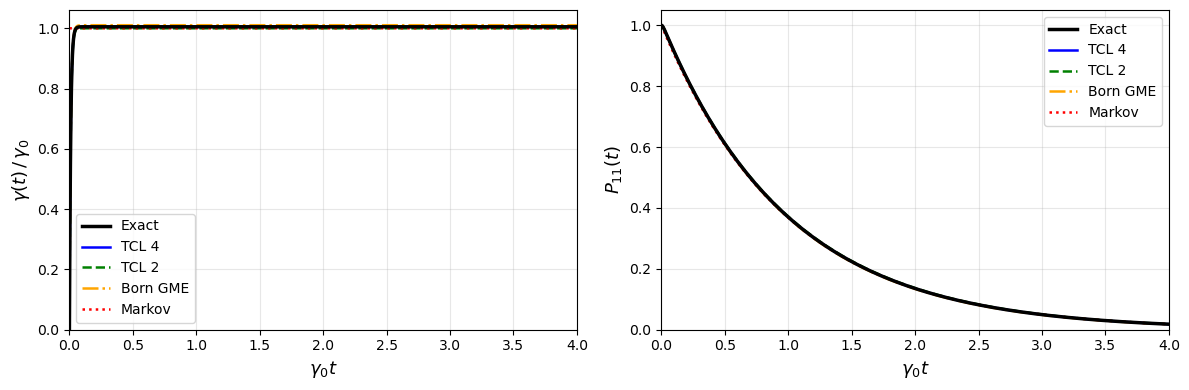

In [33]:
# --- Evaluate all schemes for the moderate coupling regime ---
P11_mod        = P11_exact(t_mod, gamma0, Lambda_moderate)
gamma_mod      = gamma_exact(t_mod, gamma0, Lambda_moderate)
P11_tcl2_mod   = P11_tcl2(t_mod, gamma0, Lambda_moderate)
gamma_tcl2_mod = gamma_tcl2(t_mod, gamma0, Lambda_moderate)
P11_tcl4_mod   = P11_tcl4(t_mod, gamma0, Lambda_moderate)
gamma_tcl4_mod = gamma_tcl4_total(t_mod, gamma0, Lambda_moderate)
P11_born_mod   = P11_born_gme(t_mod, gamma0, Lambda_moderate)
gamma_born_mod = gamma_born_gme(t_mod, gamma0, Lambda_moderate)

# --- Evaluate all schemes for the strong coupling regime ---
P11_str        = P11_exact(t_str, gamma0, Lambda_strong)
gamma_str      = gamma_exact(t_str, gamma0, Lambda_strong)
P11_tcl2_str   = P11_tcl2(t_str, gamma0, Lambda_strong)
gamma_tcl2_str = gamma_tcl2(t_str,  gamma0, Lambda_strong)
P11_tcl4_str   = P11_tcl4(t_str,    gamma0, Lambda_strong)
gamma_tcl4_str = gamma_tcl4_total(t_str,  gamma0, Lambda_strong)
P11_born_str   = P11_born_gme(t_str, gamma0, Lambda_strong)
gamma_born_str = gamma_born_gme(t_str, gamma0, Lambda_strong)

# --- Create the figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- Panel (a): decay rate in the moderate coupling regime
ax = axes[0]
ax.plot(t_mod, gamma_mod,        color=colors['exact'],  lw=2.5, ls='-',  label="Exact", zorder=5)
ax.plot(t_mod, gamma_tcl4_mod,   color=colors['tcl4'],   lw=1.8, ls='-',  label="TCL 4")
ax.plot(t_mod, gamma_tcl2_mod,   color=colors['tcl2'],   lw=1.8, ls='--', label="TCL 2")
ax.plot(t_mod, gamma_born_mod,   color=colors['gme'],    lw=1.8, ls='-.', label="Born GME")
ax.plot(t_mod, gamma_markov_mod, color=colors['markov'], lw=1.8, ls=':',  label="Markov")
ax.set_xlabel(r"$\gamma_0 t$",           fontsize=13)
ax.set_ylabel(r"$\gamma(t)\,/\,\gamma_0$", fontsize=13)
ax.set_xlim(0, 4)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# -- Panel (b): population in the moderate coupling regime
ax = axes[1]
ax.plot(t_mod, P11_mod,          color=colors['exact'],  lw=2.5, ls='-',  label="Exact",    zorder=5)
ax.plot(t_mod, P11_tcl4_mod,     color=colors['tcl4'],   lw=1.8, ls='-',  label="TCL 4")
ax.plot(t_mod, P11_tcl2_mod,     color=colors['tcl2'],   lw=1.8, ls='--', label="TCL 2")
ax.plot(t_mod, P11_born_mod,     color=colors['gme'],    lw=1.8, ls='-.', label="Born GME")
ax.plot(t_mod, P11_markov_mod,   color=colors['markov'], lw=1.8, ls=':',  label="Markov")
ax.set_xlabel(r"$\gamma_0 t$", fontsize=13)
ax.set_ylabel(r"$P_{11}(t)$",  fontsize=13)
ax.set_xlim(0, 4)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel (c): decay rate, strong coupling
# Note: gamma(t) diverges at zeros of P11 in strong coupling —
# clip the y-axis to keep the plot readable
# ax = axes[0]
# ax.plot(t_str, gamma_str,        color=colors['exact'],  lw=2.5, ls='-',  label="Exact",    zorder=5)
# # ax.plot(t_str, gamma_tcl4_str,   color=colors['tcl4'],   lw=1.8, ls='-',  label="TCL 4")
# # ax.plot(t_str, gamma_tcl2_str,   color=colors['tcl2'],   lw=1.8, ls='--', label="TCL 2")
# ax.plot(t_str, gamma_born_str,   color=colors['gme'],    lw=1.8, ls='-.', label="Born GME")
# ax.plot(t_str, gamma_markov_str, color=colors['markov'], lw=1.8, ls=':',  label="Markov")
# ax.set_xlabel(r"$\gamma_0 t$",             fontsize=13)
# ax.set_ylabel(r"$\gamma(t)\,/\,\gamma_0$", fontsize=13)
# ax.set_xlim(0, 25)
# ax.set_ylim(-2, 4)     # clip divergences for readability
# ax.axhline(0, color='gray', lw=0.8, ls=':')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

# # ── Panel (d): population, strong coupling
# ax = axes[1]
# ax.plot(t_str, P11_str,          color=colors['exact'],  lw=2.5, ls='-',  label="Exact",    zorder=5)
# ax.plot(t_str, P11_tcl4_str,     color=colors['tcl4'],   lw=1.8, ls='-',  label="TCL 4")
# ax.plot(t_str, P11_tcl2_str,     color=colors['tcl2'],   lw=1.8, ls='--', label="TCL 2")
# ax.plot(t_str, P11_born_str,     color=colors['gme'],    lw=1.8, ls='-.', label="Born GME")
# ax.plot(t_str, P11_markov_str,   color=colors['markov'], lw=1.8, ls=':',  label="Markov")
# ax.axhline(0, color='gray', lw=0.8, ls=':')
# ax.set_xlabel(r"$\gamma_0 t$", fontsize=13)
# ax.set_ylabel(r"$P_{11}(t)$",  fontsize=13)
# ax.set_xlim(0, 25)
# ax.set_ylim(-0.15, 1.05)
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure1_all_coupling.pdf", dpi=150, bbox_inches="tight")
plt.show()

t_test = np.linspace(0, 25, 1000)
g_test = gamma_exact(t_test, gamma0, Lambda_strong)
P_test = P11_exact(t_test, gamma0, Lambda_strong)

## Figure 2 -- Deviations and Strong Coupling

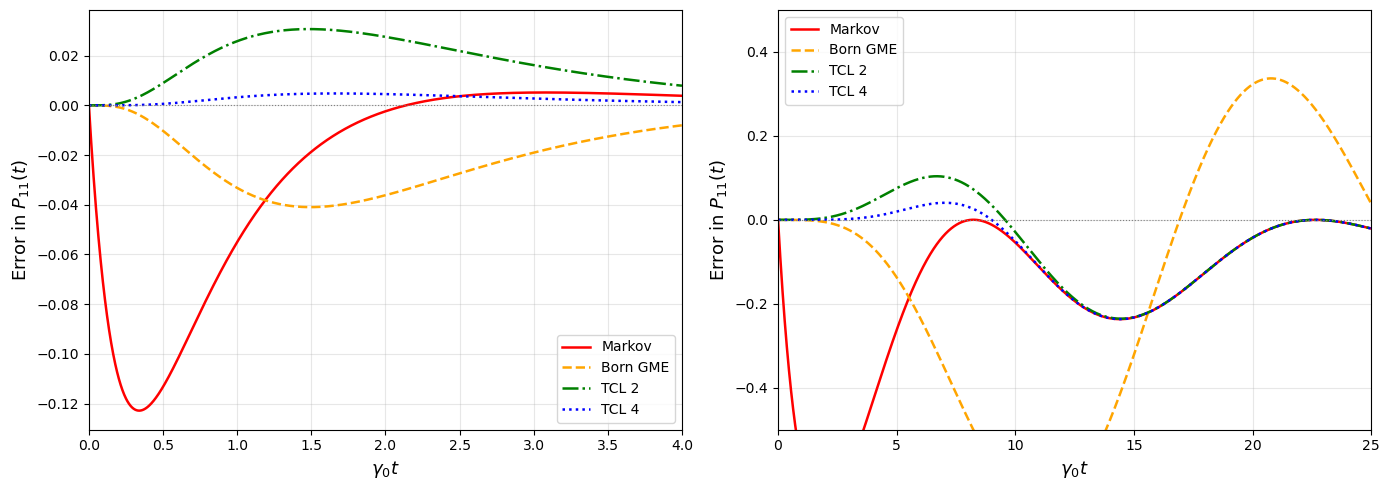

P11_markov_mod at t=1: 0.36769517973276
P11_mod at t=1:        0.4226616307436885
dP11_markov_mod at t=1: -0.05496645101092851
dP11_born_mod at t=1:   -0.03323481299908626
dP11_tcl2_mod at t=1:   0.025839731210475392
dP11_tcl4_mod at t=1:   0.003256617580351562


In [15]:
# --- Evaluate all schemes for the moderate coupling regime ---
P11_mod        = P11_exact(t_mod, gamma0, Lambda_moderate)
gamma_mod      = gamma_exact(t_mod, gamma0, Lambda_moderate)
P11_tcl2_mod   = P11_tcl2(t_mod, gamma0, Lambda_moderate)
gamma_tcl2_mod = gamma_tcl2(t_mod, gamma0, Lambda_moderate)
P11_tcl4_mod   = P11_tcl4(t_mod, gamma0, Lambda_moderate)
gamma_tcl4_mod = gamma_tcl4_total(t_mod, gamma0, Lambda_moderate)
P11_born_mod   = P11_born_gme(t_mod, gamma0, Lambda_moderate)
gamma_born_mod = gamma_born_gme(t_mod, gamma0, Lambda_moderate)

# --- Calculate the deviations of all approximations from the exact solution (moderate) ---
dP11_markov_mod = P11_markov_mod - P11_mod
dP11_born_mod   = P11_born_mod  - P11_mod
dP11_tcl2_mod   = P11_tcl2_mod  - P11_mod
dP11_tcl4_mod   = P11_tcl4_mod  - P11_mod

# --- Evaluate all schemes for the strong coupling regime ---
P11_str        = P11_exact(t_str, gamma0, Lambda_strong)
gamma_str      = gamma_exact(t_str, gamma0, Lambda_strong)
P11_tcl2_str   = P11_tcl2(t_str, gamma0, Lambda_strong)
gamma_tcl2_str = gamma_tcl2(t_str,  gamma0, Lambda_strong)
P11_tcl4_str   = P11_tcl4(t_str,    gamma0, Lambda_strong)
gamma_tcl4_str = gamma_tcl4_total(t_str,  gamma0, Lambda_strong)
P11_born_str   = P11_born_gme(t_str, gamma0, Lambda_strong)
gamma_born_str = gamma_born_gme(t_str, gamma0, Lambda_strong)

# --- Calculate the deviations of all approximations from the exact solution (strong) ---
dP11_markov_str = P11_markov_str - P11_str
dP11_born_str   = P11_born_str  - P11_str
dP11_tcl2_str   = P11_tcl2_str  - P11_str
dP11_tcl4_str   = P11_tcl4_str  - P11_str

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel (a): deviations, moderate coupling
ax = axes[0]

ax.plot(t_mod, dP11_markov_mod, color=colors['markov'], lw=1.8, ls='-',  label="Markov")
ax.plot(t_mod, dP11_born_mod,   color=colors['gme'],    lw=1.8, ls='--', label="Born GME")
ax.plot(t_mod, dP11_tcl2_mod,    color=colors['tcl2'],  lw=1.8, ls='-.', label="TCL 2")
ax.plot(t_mod, dP11_tcl4_mod,   color=colors['tcl4'],   lw=1.8, ls=':',  label="TCL 4")

ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel(r"$\gamma_0 t$", fontsize=13)
ax.set_ylabel(r"Error in $P_{11}(t)$", fontsize=13)
ax.set_xlim(0, 4)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel (b): deviations, strong coupling
# Note: only show up to t0 (first zero of P11) for TCL schemes
# since beyond that the perturbation expansion diverges and the
# deviations become arbitrarily large and uninformative
ax = axes[1]

ax.plot(t_str, dP11_markov_str, color=colors['markov'], lw=1.8, ls='-',  label="Markov")
ax.plot(t_str, dP11_born_str,   color=colors['gme'],    lw=1.8, ls='--', label="Born GME")
ax.plot(t_str, dP11_tcl2_str,   color=colors['tcl2'],   lw=1.8, ls='-.', label="TCL 2")
ax.plot(t_str, dP11_tcl4_str,   color=colors['tcl4'],   lw=1.8, ls=':',  label="TCL 4")

ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel(r"$\gamma_0 t$", fontsize=13)
ax.set_ylabel(r"Error in $P_{11}(t)$", fontsize=13)
ax.set_xlim(0, 25)
ax.set_ylim(-0.5, 0.5)    # clip large deviations beyond t0
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure2_deviations.pdf", dpi=150, bbox_inches="tight")
plt.show()

idx = np.argmin(np.abs(t_mod - 1.0))
print("P11_markov_mod at t=1:", P11_markov_mod[idx])
print("P11_mod at t=1:       ", P11_mod[idx])
print("dP11_markov_mod at t=1:", dP11_markov_mod[idx])
print("dP11_born_mod at t=1:  ", dP11_born_mod[idx])
print("dP11_tcl2_mod at t=1:  ", dP11_tcl2_mod[idx])
print("dP11_tcl4_mod at t=1:  ", dP11_tcl4_mod[idx])

## Figure 3 -- Convergence Analysis

  10/50 done
  20/50 done
  30/50 done
  40/50 done
Done.


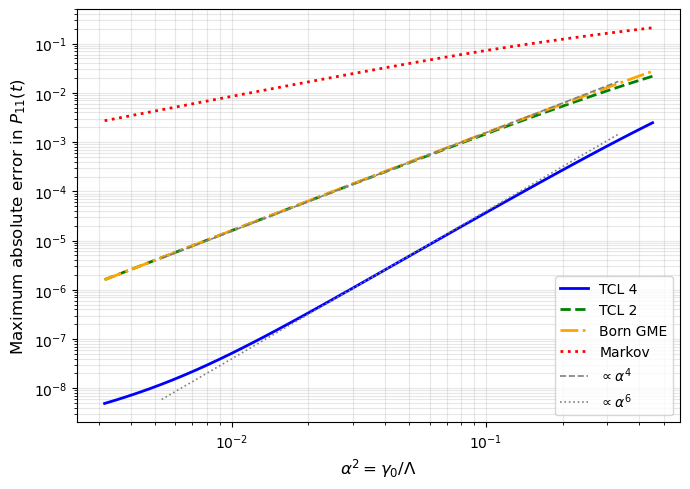

Markov log-log slope: 0.8937982171593163
TCL2 log-log slope: 1.9383169450408035
Born GME log-log slope: 1.9740270942385696


In [22]:
alpha2_values = np.logspace(-2.5, -0.3, 50)

err_tcl2_short   = np.zeros(len(alpha2_values))
err_tcl4_short   = np.zeros(len(alpha2_values))
err_markov_short = np.zeros(len(alpha2_values))
err_gme_short    = np.zeros(len(alpha2_values))

err_tcl2_long    = np.zeros(len(alpha2_values))
err_tcl4_long    = np.zeros(len(alpha2_values))
err_markov_long  = np.zeros(len(alpha2_values))
err_gme_long     = np.zeros(len(alpha2_values))

for i, alpha2 in enumerate(alpha2_values):
    Lambda = gamma0 / alpha2

    # Only weak coupling
    if Lambda <= 2 * gamma0:
        for arr in [err_tcl2_short, err_tcl4_short, err_markov_short,
                    err_gme_short, err_tcl2_long, err_tcl4_long,
                    err_markov_long, err_gme_long]:
            arr[i] = np.nan
        continue

    # Short-time window: t in [0, 2/Lambda]
    t_short = np.linspace(1e-8, 2.0 / Lambda, 500)

    # Long-time window: t in [2/gamma0, 10/gamma0]
    t_long = np.linspace(1.0 / gamma0, 4.0 / gamma0, 500)

    # ── Evaluate all schemes on both time windows
    for t_win, err_t2, err_t4, err_mk, err_gm in [
        (t_short, err_tcl2_short, err_tcl4_short,
                  err_markov_short, err_gme_short),
        (t_long,  err_tcl2_long,  err_tcl4_long,
                  err_markov_long, err_gme_long)
    ]:
        P_exact = P11_exact(t_win, gamma0, Lambda)
        P_mk    = np.exp(-gamma0 * t_win)
        P_t2    = P11_tcl2(t_win, gamma0, Lambda)
        P_t4    = P11_tcl4(t_win, gamma0, Lambda)

        def gme_ode(t_val, y):
            return [y[1], -Lambda * y[1] - gamma0 * Lambda * y[0]]
        sol = solve_ivp(gme_ode, [t_win[0], t_win[-1]], [1.0, 0.0],
                        t_eval=t_win, method='RK45',
                        rtol=1e-10, atol=1e-12)
        P_gme = sol.y[0]

        err_t2[i] = np.max(np.abs(P_t2  - P_exact))
        err_t4[i] = np.max(np.abs(P_t4  - P_exact))
        err_mk[i] = np.max(np.abs(P_mk  - P_exact))
        err_gm[i] = np.max(np.abs(P_gme - P_exact))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(alpha2_values)} done")

print("Done.")

# ── Reference slope lines
ref_a2    = np.array([alpha2_values[5], alpha2_values[-5]])

# Anchor to TCL2 short-time data
valid     = ~np.isnan(err_tcl2_short)
mid       = np.where(valid)[0][len(np.where(valid)[0])//2]
scale_4s  = err_tcl2_short[mid] / alpha2_values[mid]**2
scale_6s  = err_tcl4_short[mid] / alpha2_values[mid]**3

# Anchor to TCL2 long-time data
mid_l     = np.where(~np.isnan(err_tcl2_long))[0][
                len(np.where(~np.isnan(err_tcl2_long))[0])//2]
scale_4l  = err_tcl2_long[mid_l]  / alpha2_values[mid_l]**2
scale_6l  = err_tcl4_long[mid_l]  / alpha2_values[mid_l]**3

# ── Plot
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Panel (a): short-time errors
plt.loglog(alpha2_values, err_tcl4_short,   color=colors['tcl4'],   lw=2, ls='-',    label="TCL 4")
plt.loglog(alpha2_values, err_tcl2_short,   color=colors['tcl2'],   lw=2, ls='--',   label="TCL 2")
plt.loglog(alpha2_values, err_gme_short,    color=colors['gme'],    lw=2, ls='-.',   label="Born GME")
plt.loglog(alpha2_values, err_markov_short, color=colors['markov'], lw=2, ls=':',    label="Markov")
plt.loglog(ref_a2, scale_4s * ref_a2**2,    color='gray',           lw=1.2, ls='--', label=r"$\propto\alpha^4$")
plt.loglog(ref_a2, scale_6s * ref_a2**3,    color='gray',           lw=1.2, ls=':',  label=r"$\propto\alpha^6$")

plt.xlabel(r"$\alpha^2 = \gamma_0/\Lambda$", fontsize=12)
plt.ylabel("Maximum absolute error in $P_{11}(t)$", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("figure3_convergence.pdf", dpi=150, bbox_inches="tight")
plt.show()

# Fit the slope of the Markov error on the log-log plot
valid = ~np.isnan(err_markov_short)
coeffs = np.polyfit(np.log10(alpha2_values[valid]), 
                    np.log10(err_markov_short[valid]), 1)
print("Markov log-log slope:", coeffs[0])

# Same for TCL2 and Born GME
coeffs_t2 = np.polyfit(np.log10(alpha2_values[valid]),
                       np.log10(err_tcl2_short[valid]), 1)
print("TCL2 log-log slope:", coeffs_t2[0])

coeffs_gme = np.polyfit(np.log10(alpha2_values[valid]),
                        np.log10(err_gme_short[valid]), 1)
print("Born GME log-log slope:", coeffs_gme[0])

## Figure 4 -- Validity Map

  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done
Done.


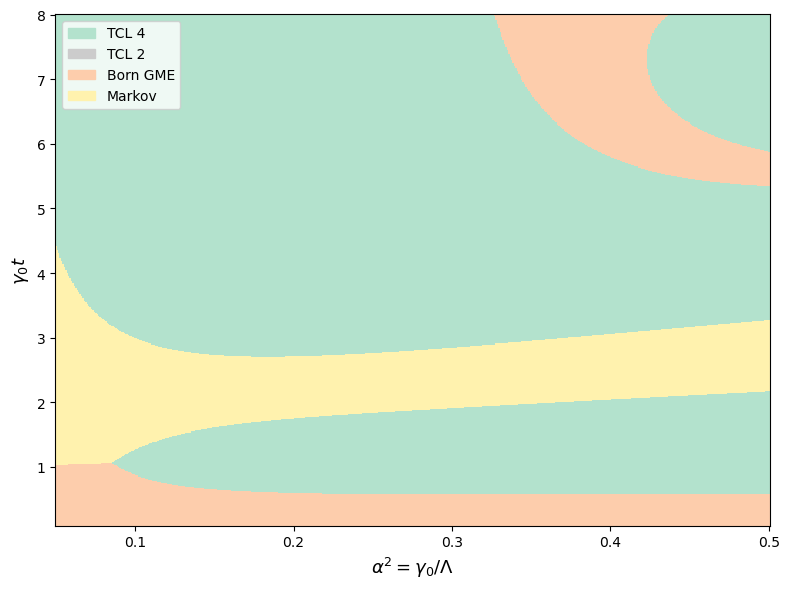

In [18]:
# Creates a 500x500 grid of points. Each column represents a specific \alpha^2 (coupling strength) value,
# while each row represents a specific time value.
alpha2_range = np.linspace(0.05, 0.5, 500)
t_range      = np.linspace(0.1, 8.0, 500)

# Creates an empty grid to fill in during the loop.
# Creates a 2D array of integers, one row for each time value and one column for each \alpha^2 value
best_map = np.zeros((len(t_range), len(alpha2_range)), dtype=int)

for i, alpha2 in enumerate(alpha2_range):
  # Compute \Lambda for each \alpha^2 value
  Lambda = gamma0/alpha2

  # Now evaluate all four approximation schemes and the exact solution for the full time array at once
  P_exact = P11_exact(t_range, gamma0, Lambda)
  P_t4    = P11_tcl4(t_range, gamma0, Lambda)
  P_t2    = P11_tcl2(t_range, gamma0, Lambda)
  P_gme   = P11_born_gme(t_range, gamma0, Lambda)
  P_mk    = np.exp(-gamma0 * t_range)

  # At each time (so, each (time, coupling) point), compute the absolute error of each approximation
  # relative to the exact solution, and store the index of which has the smallest error.
  # np.argmin will return 0 for TCL4, 1 for TCL2, 2 for GME, and 3 for Markov.
  for j, t_val in enumerate(t_range):
    errs = [
      abs(P_t4[j] - P_exact[j]),  # TCL4
      abs(P_t2[j] - P_exact[j]),  # TCL2
      abs(P_gme[j] - P_exact[j]), # Born GME
      abs(P_mk[j] - P_exact[j]),  # Markov
    ]
    best_map[j, i] = np.argmin(errs)

  # Every 20 calculations, print iteration count
  if (i + 1) % 50 == 0:
    print(f"  {i+1}/{len(alpha2_range)} done")

print("Done.")

# --- Plot everything ---
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors from Pastel2
base_cmap     = matplotlib.colormaps.get_cmap('Pastel2')
scheme_colors = [base_cmap(0),   # TCL 4
                 base_cmap(7),   # TCL 2
                 base_cmap(1),   # Born GME
                 base_cmap(5)]   # Markov
scheme_labels = ['TCL 4', 'TCL 2', 'Born GME', 'Markov']

cmap = mcolors.ListedColormap(scheme_colors)
im = ax.pcolormesh(alpha2_range, t_range, best_map,
                   cmap=cmap, vmin=-0.5, vmax=3.5,
                   shading='auto')

ax.set_xlabel(r"$\alpha^2 = \gamma_0/\Lambda$", fontsize=13)
ax.set_ylabel(r"$\gamma_0 t$",                  fontsize=13)

# Legend
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(scheme_colors, scheme_labels)]
ax.legend(handles=patches, fontsize=10, loc='upper left')

ax.grid(False)
plt.tight_layout()
plt.savefig("figure4_validity_map.pdf", dpi=150, bbox_inches="tight")
plt.show()